In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

## Processing of dose and LET data in water phantom

This is the data that I got from running a simulation in a water phantom. In the file 'LET analysis from Raysation.ipynb' I verify that the dose curves that I obtain from there closely match those from RayPhysics.

In [2]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\roi_let_dose_coords_WaterPhantom.csv"
data_waterphantom = pd.read_csv(path)

#Find middle x and y
x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

#Extract data with this x and y
lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]
print(lineprofile)

          x_mm     y_mm    z_mm  LET_keV_per_um   Dose_Gy  LET_vektet_dose
667898 -0.2404 -135.029 -225.05        2.741313  0.000041         0.000047
667993 -0.2404 -134.729 -225.05        2.714425  0.000016         0.000019
668088 -0.2404 -134.429 -225.05        0.000000  0.000000         0.000000
668183 -0.2404 -134.129 -225.05        2.377136  0.000006         0.000007
668278 -0.2404 -133.829 -225.05        2.904258  0.000067         0.000078
...        ...      ...     ...             ...       ...              ...
685473 -0.2404  -79.529 -225.05        1.132318  0.470687         0.500000
685568 -0.2404  -79.229 -225.05        1.061322  0.465998         0.493200
685663 -0.2404  -78.929 -225.05        1.059537  0.466506         0.493691
685758 -0.2404  -78.629 -225.05        1.059925  0.464723         0.491815
685853 -0.2404  -78.329 -225.05        1.039072  0.459429         0.485684

[190 rows x 6 columns]


In [3]:
#Process data
ydata = np.array(abs(lineprofile['y_mm']))
letdata = np.array(lineprofile['LET_keV_per_um'])
dosedata = np.array(lineprofile['Dose_Gy'])

#Want depth to start at zero
ydata = ydata - min(ydata)
#Sort depth data in ascending order
sort = np.argsort(ydata)
#Apply sorting to all variables
ydata = ydata[sort]
letdata = letdata[sort]
dosedata = dosedata[sort]

#Truncate data once dose drops to zero
stopindex = np.where(dosedata==0)[0][0]
ydata = ydata[0:stopindex]
letdata = letdata[0:stopindex]
dosedata = dosedata[0:stopindex]

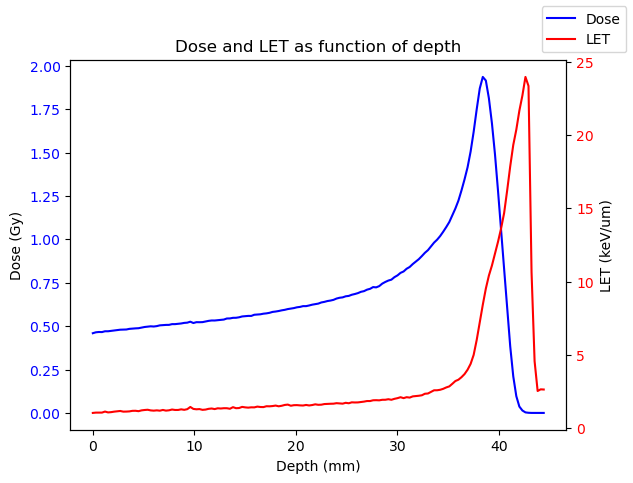

In [4]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(ydata, dosedata, label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('Dose (Gy)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(ydata, letdata, label='LET', color='r')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Dose and LET as function of depth')

handles = []
labels = []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels)

Interpolate data to get a useful lookup table

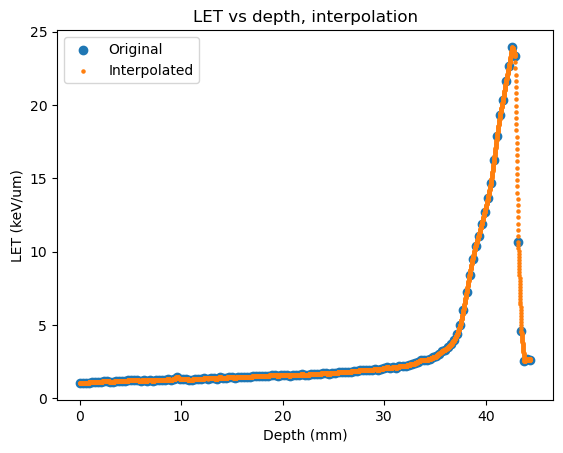

In [5]:
#interpolate data to get depth in steps of 0.01 mm
LET_interp = pd.DataFrame(columns=['Depth', 'LET'])
LET_interp['Depth'] = np.arange(ydata[0], ydata[-1], 0.01)

LET_interp['LET'] = np.interp(LET_interp['Depth'], ydata, letdata)

plt.scatter(ydata, letdata, label='Original')
plt.scatter(LET_interp['Depth'], LET_interp['LET'], label='Interpolated', s=5)
plt.title('LET vs depth, interpolation')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.legend()

In [26]:
LET_interp['Dose'] = np.interp(LET_interp['Depth'], ydata, dosedata)

entrance_dose = LET_interp['Dose'].iloc[1179]
print(LET_interp.iloc[1179])

#Isolate back end of Bragg peak
back_Bragg = LET_interp.iloc[np.argmax(np.array(LET_interp['Dose'])):len(LET_interp)]
back_Bragg['Diff'] = abs(back_Bragg['Dose'] - entrance_dose)

print(back_Bragg.iloc[np.argmin(np.array(back_Bragg['Diff']))])

Depth    11.790000
LET       1.328522
Dose      0.532794
Name: 1179, dtype: float64
Depth    40.900000
LET      16.770389
Dose      0.530248
Diff      0.002546
Name: 4090, dtype: float64


C:\Users\bhaan\AppData\Local\Temp\ipykernel_25288\2643853653.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  back_Bragg['Diff'] = abs(back_Bragg['Dose'] - entrance_dose)


## Analysis of curves from RayPhysics

This is the curve with measured data from RayPhysics.

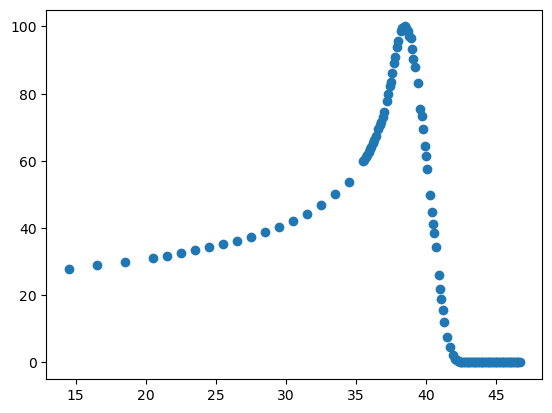

In [19]:
path = r"C:\Users\bhaan\Downloads\MeasuredBP_69MeV.xlsx"
data = pd.read_excel(path)

RSdepth_m = np.array(data['Depth'])
RSdose_m = np.array(data['Dose'])

#Sort depth data in ascending order
sort = np.argsort(RSdepth_m)
#Apply sorting to all variables
RSdepth_m = RSdepth_m[sort]
RSdose_m = RSdose_m[sort]

RS = pd.DataFrame(columns=['Depth', 'Dose'])
RS['Depth'] = RSdepth_m
RS['Dose'] = RSdose_m

plt.scatter(RS['Depth'], RS['Dose'])

In [20]:
#Isolate entrance dose
entrance_dose = RS['Dose'].iloc[0]
print(RS.iloc[0])

#Isolate back end of Bragg peak
back_Bragg = RS.iloc[np.argmax(np.array(RS['Dose'])):len(RS)]
back_Bragg['Diff'] = abs(back_Bragg['Dose'] - entrance_dose)

print(back_Bragg.iloc[np.argmin(np.array(back_Bragg['Diff']))])

Depth    14.51
Dose     27.88
Name: 0, dtype: float64
Depth    40.91
Dose     25.92
Diff      1.96
Name: 65, dtype: float64


C:\Users\bhaan\AppData\Local\Temp\ipykernel_25288\24292409.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  back_Bragg['Diff'] = abs(back_Bragg['Dose'] - entrance_dose)


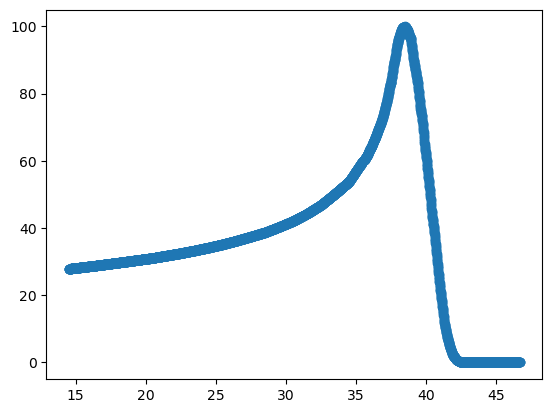

In [23]:
RS_int = pd.DataFrame(columns=['Depth', 'Dose'])
RS_int['Depth'] = np.arange(RSdepth_m[0], RSdepth_m[-1], 0.01)
RS_int['Dose'] = np.interp(RS_int['Depth'], RSdepth_m, RSdose_m)

plt.scatter(RS_int['Depth'], RS_int['Dose'])